# Financial Fraud Detection: Machine Learning with Graph Features

In this notebook, we demonstrate how to combine traditional tabular data with **Graph Features** to train a machine learning model for fraud detection. In [loader.ipynb](loader.ipynb), we constructed a Neo4j graph database from the IEEE-CIS Fraud Detection dataset. Here, we will use Neo4j as a feature store to extract relevant data necessary to train our model, as well as to compute additional graph connected features.

> The goal is not trying to create a state-of-the-art fraud detection model, or one which would win any competitions. Instead, we want to illustrate how graph features can be integrated into a machine learning workflow to potentially enhance model performance. Think of this as a **Graph-Enhanced Baseline Model**, rather than a production-ready solution - we only use a subset of features and a simple model for clarity, missing out on advanced feature engineering, hyperparameter tuning, and model selection.

The following is the workflow we will follow for the model training and evaluation:

- **Feature Engineering (in Neo4j):** We use the **Graph Data Science (GDS)** library to calculate centrality and community metrics directly in the database.
- **Data Extraction:** We query the graph to create a dataset that includes both transaction properties (Amount, Time) and graph features (PageRank, Community Size).
- **Model Training:** We train an **[XGBoost](https://xgboost.readthedocs.io/en/stable/)** classifier on this graph-enhanced dataset.
- **Evaluation:** We measure performance using ROC-AUC and Precision-Recall curves, and compare performance with and without graph features.

The graph approach enables the model to learn from the network signals in the graph (e.g., "Is this user part of a fraud ring?"), not just individual columnar attributes typical of tabular data, further improving its ability to successfully detect fraudulent activity.

In [1]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from neo4j import GraphDatabase
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import average_precision_score, roc_auc_score, confusion_matrix

NEO4J_URI = os.getenv("NEO4J_URI")
NEO4J_USER = os.getenv("NEO4J_USER")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")
NEO4J_TRAIN_DB = os.getenv("NEO4J_TRAIN_DATABASE")
NEO4J_TEST_DB = os.getenv("NEO4J_TEST_DATABASE")

## Graph Pipeline & GDS Setup

We define a `Neo4jGraphPipeline` class to handle interactions with the Neo4j Graph Data Science (GDS) library. This helper manages:
*   **Graph Projection:** Loading a subgraph into memory for analysis.
*   **Feature Engineering:** Running algorithms like **PageRank**, **Degree Centrality**, and **Louvain**.
*   **Cleanup:** Dropping projections to free up memory.

In [2]:
class Neo4jGraphPipeline:
    def __init__(self, uri, user, password, database):
        self.driver = GraphDatabase.driver(uri, auth=(user, password))
        self.database = database

    def close(self):
        self.driver.close()

    def run_query(self, query, params=None):
        with self.driver.session(database=self.database) as session:
            result = session.run(query, params or {})
            return [record.data() for record in result]

    def run_gds_algorithm(self, query):
        """
        Run a GDS query and force the driver to wait for completion.
        Raises an exception if the server-side execution fails.
        """
        print(f"   > Executing GDS Task...")
        with self.driver.session(database=self.database) as session:
            # Run the query
            result = session.run(query)
            
            # CRITICAL: .data() or .consume() forces the driver to wait 
            # for the server to finish the job and return the status/error.
            # GDS procedures always yield stats (like 'nodesWritten'), so this is safe.
            stats = result.data() 
            
            # Optional: Print stats to confirm success
            if stats:
                print(f"   > Success. Stats: {stats[0]}")
            else:
                print("   > Warning: Query finished but returned no stats.")
            
    def project_graph(self, graph_name):
        """
        Projects a graph into memory for GDS analysis.
        We project ALL nodes and relationships to capture the full network topology.
        
        CRITICAL UPDATE:
        We define node properties for ALL labels with defaultValues. 
        This ensures GraphSAGE can calculate embeddings even when a Transaction 
        is connected to a Card/Device that lacks the 'amt' or 'dist1' property.
        """
        print(f"Projecting graph '{graph_name}' in {self.database}...")
        
        # Check if exists and drop
        exists = self.run_query(f"CALL gds.graph.exists('{graph_name}') YIELD exists RETURN exists")[0]['exists']
        if exists:
            self.run_gds_algorithm(f"CALL gds.graph.drop('{graph_name}') YIELD graphName")

        # Project new graph (Native projection for all nodes/rels)
        query = f"""
        CALL gds.graph.project(
                '{graph_name}',
                ['Transaction', 'Card', 'Address', 'Email', 'Device'],
                {{
                    USED_CARD: {{orientation: 'UNDIRECTED'}},
                    BILLED_TO: {{orientation: 'UNDIRECTED'}},
                    PURCHASER_EMAIL: {{orientation: 'UNDIRECTED'}},
                    RECIPIENT_EMAIL: {{orientation: 'UNDIRECTED'}},
                    ON_DEVICE: {{orientation: 'UNDIRECTED'}}
                }}
            )   
        """
        self.run_gds_algorithm(query)
        print(f"Graph '{graph_name}' projected.")

    def run_feature_engineering(self, graph_name):
        """
        Runs PageRank, Degree Centrality, Louvain, and Fraud Proximity.
        Writes results back to Transaction nodes.
        """
        print(f"Running Feature Engineering on {self.database}...")
        
        # PageRank: Measures influence/importance of nodes
        print(" - Running PageRank...")
        self.run_gds_algorithm(f"""
        CALL gds.pageRank.write('{graph_name}', {{
            writeProperty: 'pageRank',
            dampingFactor: 0.85,
            maxIterations: 100
        }})
        """)
        
        # Degree Centrality: Measures volume of connections
        print(" - Running Degree Centrality...")
        self.run_gds_algorithm(f"""
        CALL gds.degree.write('{graph_name}', {{
            writeProperty: 'degree'
        }})
        """)
        
        # Louvain (Community Detection) - Replaces WCC
        # Finds dense clusters of transactions, even if they share common attributes.
        print(f" - Running Louvain (Community Detection)...")
        self.run_gds_algorithm(f"""
            CALL gds.louvain.write('{graph_name}', {{
                writeProperty: 'communityId',
                maxIterations: 100,
                tolerance: 0.0001,
                consecutiveIds: true
            }})
        """)
        
        # Calculate Community Size
        print(" - Calculating Community Sizes...")
        self.run_gds_algorithm("""
            MATCH (t:Transaction)
            WHERE t.communityId IS NOT NULL
            WITH t.communityId AS cId, count(t) AS size
            MATCH (t:Transaction) WHERE t.communityId = cId
            SET t.communitySize = size
        """)
        print(" - Louvain Communities and Sizes calculated.")
        
        # FastRP (Node Embeddings)
        print(f"- Running FastRP...")
        self.run_gds_algorithm(f"""
            CALL gds.fastRP.write('{graph_name}', {{
                embeddingDimension: 32,      
                iterationWeights: [0.0, 0.0, 1.0, 1.0], 
                normalizationStrength: 0.5,
                writeProperty: 'fastRP_embedding'
            }})
        """)
        
        # Monetary Velocity
        print(" - Calculating Monetary Velocity...")
        self.run_gds_algorithm("""
            MATCH (t:Transaction)
            WHERE t.communityId IS NOT NULL
            WITH t.communityId AS cId, 
                sum(t.amt) AS totalVolume, 
                max(t.timestamp) - min(t.timestamp) AS duration
            MATCH (t:Transaction) WHERE t.communityId = cId
            SET t.g_communityValueVelocity = CASE 
                WHEN duration > 0 THEN totalVolume / (duration / 3600.0) // USD per hour
                ELSE totalVolume 
                END
        """)
        
        # Community Expansion Rate
        print(" - Calculating Community Expansion Rate...")
        self.run_gds_algorithm("""
            MATCH (t:Transaction)
            WHERE t.communityId IS NOT NULL
            OPTIONAL MATCH (t)-[:USED_CARD]->(c:Card)
            WITH t.communityId AS cId, 
                count(DISTINCT c) AS uniqueCards, 
                max(t.timestamp) - min(t.timestamp) AS duration
            MATCH (t:Transaction) WHERE t.communityId = cId
            SET t.g_cardExpansionVelocity = CASE 
                WHEN duration > 0 THEN uniqueCards / (duration / 3600.0) 
                ELSE uniqueCards 
                END
        """)
        
        print("Feature engineering complete.")

    def drop_graph(self, graph_name):
        self.run_gds_algorithm(f"CALL gds.graph.drop('{graph_name}') YIELD graphName")

## Running Graph Data Science Algorithms

Here, we execute the feature engineering pipeline on both the **Train** and **Test** databases.

We calculate several key graph features for every node:

- **PageRank:** Measures the relative importance of a node (e.g., a device used by many high-value cards).
- **Degree Centrality:** Counts the number of direct connections (e.g., how many cards has this device used?).
- **Community Size:** Identifies how large the connected group is (e.g., is this transaction part of a huge cluster or isolated?).
- **Node Embeddings (FastRP):** Generates vector representations of nodes capturing their structural roles in the graph.
- **Community Value Velocity:** Measures the rate of change in the total transaction value within a community over time.
- **Card Expansion Velocity:** Measures the rate at which new cards are used within a community over time.

Depending on the nature of a specific transactional environment, these features can help identify nodes that are unusually central or connected, which may indicate fraudulent behavior. The effectiveness of these features will depend on the specific fraud patterns present in the data. Also, other graph patterns may be more relevant in different contexts - for example, cycles of transactions, or specific subgraph motifs.

In [3]:
# Feature Engineering on TRAIN Database
train_pipeline = Neo4jGraphPipeline(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD, NEO4J_TRAIN_DB)
try:
    train_pipeline.project_graph('fraud-train')
    train_pipeline.run_feature_engineering('fraud-train')
    train_pipeline.drop_graph('fraud-train') # Cleanup memory
finally:
    train_pipeline.close()

# Feature Engineering on TEST Database
test_pipeline = Neo4jGraphPipeline(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD, NEO4J_TEST_DB)
try:
    test_pipeline.project_graph('fraud-test')
    test_pipeline.run_feature_engineering('fraud-test')
    test_pipeline.drop_graph('fraud-test')
finally:
    test_pipeline.close()

Projecting graph 'fraud-train' in ieee-cis-fraud-train...
   > Executing GDS Task...
   > Success. Stats: {'nodeProjection': {'Email': {'properties': {}, 'label': 'Email'}, 'Transaction': {'properties': {}, 'label': 'Transaction'}, 'Address': {'properties': {}, 'label': 'Address'}, 'Device': {'properties': {}, 'label': 'Device'}, 'Card': {'properties': {}, 'label': 'Card'}}, 'relationshipProjection': {'ON_DEVICE': {'orientation': 'UNDIRECTED', 'aggregation': 'DEFAULT', 'type': 'ON_DEVICE', 'properties': {}, 'indexInverse': False}, 'BILLED_TO': {'orientation': 'UNDIRECTED', 'aggregation': 'DEFAULT', 'type': 'BILLED_TO', 'properties': {}, 'indexInverse': False}, 'PURCHASER_EMAIL': {'orientation': 'UNDIRECTED', 'aggregation': 'DEFAULT', 'type': 'PURCHASER_EMAIL', 'properties': {}, 'indexInverse': False}, 'USED_CARD': {'orientation': 'UNDIRECTED', 'aggregation': 'DEFAULT', 'type': 'USED_CARD', 'properties': {}, 'indexInverse': False}, 'RECIPIENT_EMAIL': {'orientation': 'UNDIRECTED', 'aggre

## Creating the Dataset (Graph + Tabular)

Now that the graph features (PageRank, Degree, Community Size, etc.) are written back to the `Transaction` nodes in Neo4j, we verify and extract them along with the original transaction data.

We use Cypher's `OPTIONAL MATCH` to retrieve related entities (Cards, Addresses, Emails) and their properties, flattening the graph structure into a tabular format suitable for XGBoost.

We also map our column names back to the original dataset for clarity, and so we can compare apples to apples in relation to the IEEE-CIS Fraud Detection dataset.

> The attentive reader will notice that the following extraction ends by ordering the columns by `t.timestamp`. This is to ensure that when we split into train and test sets later, we are respecting the temporal order of transactions, which is crucial in fraud detection scenarios to avoid data leakage.

In [4]:
def extract_data(pipeline, is_train=True):
    # Conditionally include the label for the training set
    label_query = "t.isFraud AS label," if is_train else ""
    
    # We use OPTIONAL MATCH because not every transaction has every relationship 
    # (e.g., some might lack an email or address).
    query = f"""
    MATCH (t:Transaction)
    
    // Traverse to related Hub Nodes to get features
    OPTIONAL MATCH (t)-[:USED_CARD]->(c:Card)
    OPTIONAL MATCH (t)-[:BILLED_TO]->(a:Address)
    OPTIONAL MATCH (t)-[:PURCHASER_EMAIL]->(pe:Email)
    OPTIONAL MATCH (t)-[:RECIPIENT_EMAIL]->(re:Email)
    OPTIONAL MATCH (t)-[:ON_DEVICE]->(d:Device)
    
    RETURN 
        t.id AS TransactionID,
        t.timestamp AS TransactionDT,
        t.amt AS TransactionAmt,
        t.product AS ProductCD,
        t.M1 AS M1,
        t.M2 AS M2,
        t.M3 AS M3,
        t.M4 AS M4,
        t.M5 AS M5,
        t.M6 AS M6,
        t.M7 AS M7,
        t.M8 AS M8,
        t.M9 AS M9,
        
        // Card Features (Mapped from Card Node)
        c.card1 AS card1,
        c.card2 AS card2,
        c.card3 AS card3,
        c.network AS card4,   
        c.card5 AS card5,
        c.type AS card6,      
        
        // Address Features (Mapped from Address Node)
        a.zip AS addr1,       
        a.country AS addr2,   
        
        // Email Features (Mapped from Email Nodes)
        pe.domain AS P_emaildomain,
        re.domain AS R_emaildomain,
        
        // Device Features (Mapped from Device Node)
        d.type AS DeviceType,
        d.model AS DeviceInfo,
        d.browser AS id_31,
        d.os AS id_30,
        d.resolution AS id_33,
        
        
        // Computed Graph Features
        t.pageRank AS g_pageRank,
        t.communitySize AS g_communitySize,
        toString(t.communityId) AS g_communityId,
        t.fastRP_embedding AS embedding,
        t.g_communityValueVelocity AS g_communityValueVelocity,
        t.g_cardExpansionVelocity AS g_cardExpansionVelocity,
        
        // The synthetic "Anchors" for temporal features
        t.D1n AS D1n,
        t.D2n AS D2n,
        t.D3n AS D3n,
        t.D4n AS D4n,
        t.D5n AS D5n,
        t.D6n AS D6n,
        t.D7n AS D7n,
        t.D8n AS D8n,
        t.D9n AS D9n,
        t.D10n AS D10n,
        t.D11n AS D11n,
        t.D12n AS D12n,
        t.D13n AS D13n,
        t.D14n AS D14n,
        t.D15n AS D15n,
        
        // The UID profile (behavioral aggregates)
        t.uid_count AS uid_count,
        t.uid_amt_mean AS uid_amt_mean,
        t.uid_amt_std AS uid_amt_std,
        t.uid_amt_zscore AS uid_amt_zscore,
        
        // Connectivity
        // "Is the device/card I'm using highly connected?" (Bot detection)
        // These rely on Degree Centrality having been run on the WHOLE projection
        c.degree AS card_degree,
        d.degree AS device_degree,
        pe.degree AS p_email_degree,
        re.degree AS r_email_degree,
        a.degree AS address_degree,   
        
        {label_query}
        
        // Additional Distances if needed
        t.dist1 AS dist1,
        t.dist2 AS dist2
        
    ORDER BY t.timestamp ASC
    """
    return pd.DataFrame(pipeline.run_query(query))

# Extract Train Data
print("Extracting Training Data...")
train_pipeline = Neo4jGraphPipeline(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD, NEO4J_TRAIN_DB)
df_train = extract_data(train_pipeline, is_train=True)
train_pipeline.close()

# Extract Test Data
print("Extracting Test Data...")
test_pipeline = Neo4jGraphPipeline(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD, NEO4J_TEST_DB)
df_test = extract_data(test_pipeline, is_train=False)
test_pipeline.close()

print(f"Train Shape: {df_train.shape}")
print(f"Test Shape:  {df_test.shape}")

# Preview to verify columns
df_train.head()

Extracting Training Data...
Extracting Test Data...


Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `browser` does not exist in database `ieee-cis-fraud-test`. Verify that the spelling is correct.', position=<SummaryInputPosition line=45, column=11, offset=1243>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 1243, 'line': 45, 'column': 11}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n    MATCH (t:Transaction)\n\n    // Traverse to related Hub Nodes to get features\n    OPTIONAL MATCH (t)-[:USED_CARD]->(c:Card)\n    OPTIONAL MATCH (t)-[:BILLED_TO]->(a:Address)\n    OPTIONAL MATCH (t)-[:PURCHASER_EMAIL]->(pe:Email)\n    OPTIONAL MATCH (t)-[:RECIPIENT_EMAIL]->(re:Email)\n   

Train Shape: (590540, 61)
Test Shape:  (506691, 60)


,TransactionID,TransactionDT,TransactionAmt,ProductCD,M1,M2,M3,M4,M5,M6,...,uid_amt_std,uid_amt_zscore,card_degree,device_degree,p_email_degree,r_email_degree,address_degree,label,dist1,dist2
0,2987000,86400,68.5,W,T,T,T,M2,F,T,...,0.000000,0.000000,6.0,NaN,NaN,NaN,23078.0,0,19.0,NaN
1,2987001,86401,29.0,W,NaN,NaN,NaN,M0,T,T,...,0.000000,0.000000,678.0,NaN,285502.0,NaN,42751.0,0,NaN,NaN
2,2987002,86469,59.0,W,T,T,T,M0,F,F,...,17.058722,-0.850005,1104.0,NaN,7603.0,NaN,26287.0,0,287.0,NaN
3,2987003,86499,50.0,W,NaN,NaN,NaN,M0,T,F,...,24.985305,-0.656100,4197.0,NaN,112776.0,NaN,9478.0,0,NaN,NaN
4,2987004,86506,50.0,H,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,18.0,1.0,285502.0,NaN,3581.0,0,NaN,NaN


## Preprocessing

We implement a series of standard machine learning preprocessing steps:

- **Categorical Encoding:** We use `OrdinalEncoder` for categorical fields like Product CD and Card Type.
- **Train/Validation Split:** We use a time-based split (first 80% for training) to mimic a real-world production scenario where we predict future fraud based on past data.

Depending on the algorithm chosen for your model, you may need to apply additional preprocessing steps such as scaling or normalization. XGBoost is robust to unscaled features, so we skip that step here.

In [5]:
def expand_embeddings(df, embedding_col='embedding'):
    # Inspect the data to find the dimension automatically
    # We look for the first non-null value that is actually a list
    sample_embedding = df[embedding_col].dropna().iloc[0] if not df[embedding_col].dropna().empty else []
    
    if not isinstance(sample_embedding, list) or len(sample_embedding) == 0:
        print(f"Warning: No valid embeddings found in '{embedding_col}'. Dropping column without expansion.")
        return df.drop(columns=[embedding_col], errors='ignore')
    
    # Set dim dynamically based on the data
    dim = len(sample_embedding)
    print(f"Detected embedding dimension: {dim} features.")
    
    # Expand list into a list of lists (filling NaNs with 0-vectors of the correct size)
    # Note: We use the detected 'dim' for the zero-padding
    embeddings = df[embedding_col].apply(
        lambda x: x if isinstance(x, list) and len(x) == dim else [0.0] * dim
    ).tolist()
    
    # Create a DataFrame from the embeddings
    emb_df = pd.DataFrame(embeddings, columns=[f'emb_{i}' for i in range(dim)])
    
    # CRITICAL: Align the index of the new features with the original dataframe
    # Otherwise, pd.concat might misalign rows if the df index isn't 0..N
    emb_df.index = df.index
    
    # Concatenate and drop the original list column
    df = pd.concat([df, emb_df], axis=1)
    return df.drop(columns=[embedding_col])

# Apply to Train and Test
df_train = expand_embeddings(df_train)
df_test = expand_embeddings(df_test)

print(f"New shape after embedding expansion: {df_train.shape}")

Detected embedding dimension: 32 features.
Detected embedding dimension: 32 features.
New shape after embedding expansion: (590540, 92)


In [6]:

# Identify categorical columns
cat_cols = [
    'ProductCD',
    'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
    'id_30', 'id_31', 'id_33', 'DeviceType', 'DeviceInfo',
    'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9',
    'P_emaildomain', 'R_emaildomain', 'g_communityId'
]

# Preprocessing: Fill NaNs AND cast to string
# This prevents "float < str" errors by making everything a string
for col in cat_cols:
    # Check if column exists to avoid key errors
    if col in df_train.columns:
        df_train[col] = df_train[col].fillna('unknown').astype(str)
    
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna('unknown').astype(str)

# Encode
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Fit/Transform
# Ensure we only pass the columns that actually exist in the dataframe
valid_cols = [c for c in cat_cols if c in df_train.columns]

df_train[valid_cols] = encoder.fit_transform(df_train[valid_cols])
df_test[valid_cols] = encoder.transform(df_test[valid_cols])

# Dataset is already sorted by time from extraction query

# Features and Target
X = df_train.drop(columns=['label', 'TransactionID'])
y = df_train['label']

print(f"Final Feature Count: {X.shape[1]}")
print(f"Total samples: {len(X)}")

Final Feature Count: 90
Total samples: 590540


## Model Training (XGBoost)

We continue to train an **XGBClassifier** on the processed data.

**Key Hyperparameters:**
- `scale_pos_weight`: Addresses the heavy class imbalance (fraud is rare).
- `max_depth` & `learning_rate`: Tuned to capture complex non-linear patterns without overfitting.
- `n_estimators`: Number of boosting rounds.
- `eval_metric='aucpr'`: We optimize for Area Under the Precision-Recall Curve, which is better for imbalanced datasets than accuracy, this helps the model focus on correctly identifying the minority class (fraudulent transactions).

We then fit the model on the training set and evaluate on the validation set, tracking metrics like ROC-AUC and Precision-Recall AUC.

We will run training on both the full feature set (tabular + graph) and on tabular features only, to compare performance. We also perform a time-based split, training on earlier transactions and validating on later ones to simulate real-world deployment. The splits are done so that each fold contains about 30 days of transactions.

In [7]:

from sklearn.model_selection import TimeSeriesSplit
import numpy as np

# Define Graph Features to Exclude for Comparison
embedding_cols = [c for c in X.columns if c.startswith('emb_')]
graph_features = [
    'g_pageRank', 'g_degree', 'g_communitySize', 'g_communityId',
    'device_degree', 'card_degree', 'address_degree', 'p_email_degree', 'r_email_degree',
    'g_communityValueVelocity', 'g_cardExpansionVelocity'
] + embedding_cols

# Filter only those that actually exist in the dataframe
graph_features = [c for c in graph_features if c in X.columns]

def train_xgb_model(name, X_t, y_t, X_v, y_v):
    print(f"\n{'='*40}")
    print(f"Training Model: {name}")
    print(f"Features: {X_t.shape[1]}")
    # print(f"Feature List: {list(X_t.columns)}")
    print(f"{'='*40}")

    model = xgb.XGBClassifier(
        n_estimators=3000,
        learning_rate=0.01,
        max_depth=10,
        min_child_weight=10,
        gamma=0.2,
        reg_alpha=5,
        reg_lambda=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=20,
        tree_method='hist',
        eval_metric='aucpr',
        early_stopping_rounds=200,
        random_state=42
    )

    model.fit(
        X_t, y_t,
        eval_set=[(X_t, y_t), (X_v, y_v)],
        verbose=100
    )
    
    # print(f"Best Iteration: {model.best_iteration}")
    # print(f"Best Validation AUC-PR: {model.best_score}")
    return model

# We want each split to be about 30 days apart, let us compute the the number of splits we need
n_splits = (X['TransactionDT'].max() - X['TransactionDT'].min()) // (30 * 24 * 60 * 60)

print(f"Calculated number of splits for ~30 day intervals: {n_splits}")

# Time Series Split
tscv = TimeSeriesSplit(n_splits=int(n_splits))
print(f"Starting Time Series Cross-Validation with {tscv.get_n_splits()} splits...")

results = {
    'With Graph Features': {'trues': [], 'preds': [], 'models': []},
    'Without Graph Features': {'trues': [], 'preds': [], 'models': []}
}

fold = 1
for train_index, val_index in tscv.split(X):
    print(f"\nTraining Fold {fold}...")
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]
    
    # Train with ALL Features (Tabular + Graph)
    model_with_graph = train_xgb_model(f"Fold {fold} - With Graph", X_train_fold, y_train_fold, X_val_fold, y_val_fold)
    val_probs_graph = model_with_graph.predict_proba(X_val_fold)[:, 1]
    
    results['With Graph Features']['trues'].append(y_val_fold)
    results['With Graph Features']['preds'].append(val_probs_graph)
    results['With Graph Features']['models'].append(model_with_graph)

    # Train with ONLY Tabular Features (Drop Graph)
    X_train_no_graph = X_train_fold.drop(columns=graph_features)
    X_val_no_graph = X_val_fold.drop(columns=graph_features)

    model_no_graph = train_xgb_model(f"Fold {fold} - Without Graph", X_train_no_graph, y_train_fold, X_val_no_graph, y_val_fold)
    val_probs_no_graph = model_no_graph.predict_proba(X_val_no_graph)[:, 1]
    
    results['Without Graph Features']['trues'].append(y_val_fold)
    results['Without Graph Features']['preds'].append(val_probs_no_graph)
    results['Without Graph Features']['models'].append(model_no_graph)
    
    fold += 1

# Store the 'best' model as 'model' so subsequent cells (evaluation) continue to work with the graph model
model = results['With Graph Features']['models'][-1]

Calculated number of splits for ~30 day intervals: 6
Starting Time Series Cross-Validation with 6 splits...

Training Fold 1...

Training Model: Fold 1 - With Graph
Features: 90
[0]	validation_0-aucpr:0.35497	validation_1-aucpr:0.11415
[100]	validation_0-aucpr:0.78531	validation_1-aucpr:0.31768
[200]	validation_0-aucpr:0.88381	validation_1-aucpr:0.33064
[300]	validation_0-aucpr:0.93965	validation_1-aucpr:0.34183
[400]	validation_0-aucpr:0.96649	validation_1-aucpr:0.35077
[500]	validation_0-aucpr:0.98218	validation_1-aucpr:0.35612
[600]	validation_0-aucpr:0.99083	validation_1-aucpr:0.36126
[700]	validation_0-aucpr:0.99566	validation_1-aucpr:0.36524
[800]	validation_0-aucpr:0.99795	validation_1-aucpr:0.36673
[900]	validation_0-aucpr:0.99900	validation_1-aucpr:0.36820
[1000]	validation_0-aucpr:0.99942	validation_1-aucpr:0.36920
[1100]	validation_0-aucpr:0.99960	validation_1-aucpr:0.37116
[1200]	validation_0-aucpr:0.99972	validation_1-aucpr:0.37237
[1300]	validation_0-aucpr:0.99979	validat

## Model Evaluation

Next we evaluate the model's performance on the hold-out validation set, for both the tabular-only and graph-enhanced feature sets, and for the best and worst performing folds.

- **ROC Curve:** Shows the trade-off between True Positive Rate and False Positive Rate.
- **Precision-Recall Curve:** Critical for fraud detection. It shows how many of our flagged transactions were actual fraud (Precision) vs. how much total fraud we caught (Recall).

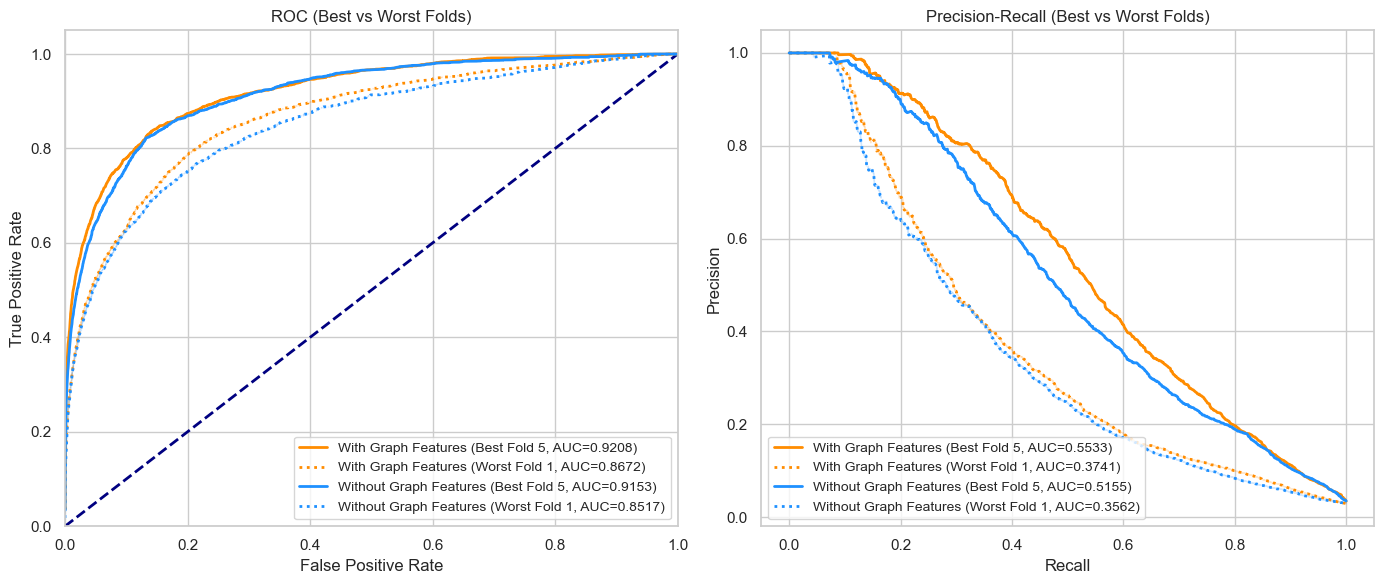

In [8]:

from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = {'With Graph Features': 'darkorange', 'Without Graph Features': 'dodgerblue'}

# Helper to find best/worst folds
def get_best_worst_folds(name, result_data):
    scores = []
    for y_t, y_p in zip(result_data['trues'], result_data['preds']):
        scores.append(average_precision_score(y_t, y_p))
    
    best_idx = np.argmax(scores)
    worst_idx = np.argmin(scores)
    
    return best_idx, worst_idx, scores

# ROC Curve
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Baseline

for name, data in results.items():
    best_idx, worst_idx, scores = get_best_worst_folds(name, data)
    
    # Best Fold
    y_true_best = data['trues'][best_idx]
    y_pred_best = data['preds'][best_idx]
    fpr, tpr, _ = roc_curve(y_true_best, y_pred_best)
    roc_auc = auc(fpr, tpr)
    sns.lineplot(x=fpr, y=tpr, color=colors[name], linewidth=2, 
                 label=f'{name} (Best Fold {best_idx+1}, AUC={roc_auc:.4f})', ax=axes[0])
    
    # Worst Fold
    y_true_worst = data['trues'][worst_idx]
    y_pred_worst = data['preds'][worst_idx]
    fpr, tpr, _ = roc_curve(y_true_worst, y_pred_worst)
    roc_auc = auc(fpr, tpr)
    sns.lineplot(x=fpr, y=tpr, color=colors[name], linestyle=':', linewidth=2, 
                 label=f'{name} (Worst Fold {worst_idx+1}, AUC={roc_auc:.4f})', ax=axes[0])

axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC (Best vs Worst Folds)')
axes[0].legend(loc="lower right", fontsize='small')

# Precision-Recall Curve
for name, data in results.items():
    best_idx, worst_idx, scores = get_best_worst_folds(name, data)

    # Best
    y_true_best = data['trues'][best_idx]
    y_pred_best = data['preds'][best_idx]
    precision, recall, _ = precision_recall_curve(y_true_best, y_pred_best)
    pr_auc = average_precision_score(y_true_best, y_pred_best)
    sns.lineplot(x=recall, y=precision, color=colors[name], linewidth=2, 
                 label=f'{name} (Best Fold {best_idx+1}, AUC={pr_auc:.4f})', ax=axes[1])
    
    # Worst
    y_true_worst = data['trues'][worst_idx]
    y_pred_worst = data['preds'][worst_idx]
    precision, recall, _ = precision_recall_curve(y_true_worst, y_pred_worst)
    pr_auc = average_precision_score(y_true_worst, y_pred_worst)
    sns.lineplot(x=recall, y=precision, color=colors[name], linestyle=':', linewidth=2,
                 label=f'{name} (Worst Fold {worst_idx+1}, AUC={pr_auc:.4f})', ax=axes[1])

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall (Best vs Worst Folds)')
axes[1].legend(loc="lower left", fontsize='small')

plt.tight_layout()
plt.show()

# Save plot to PNG file
fig.savefig("renderings/model_comparison_roc_pr.png", dpi=300)

## Feature Importance

Which features drove the model's decisions?

Let us visualize the top features for both the tabular-only and graph-enhanced models. In a successful graph ML project, we expect to see **Graph Features** (like `device_degree` or `g_communitySize`) ranking highly alongside traditional signals like Transaction Amount. This confirms that the network structure provides valuable predictive signal.

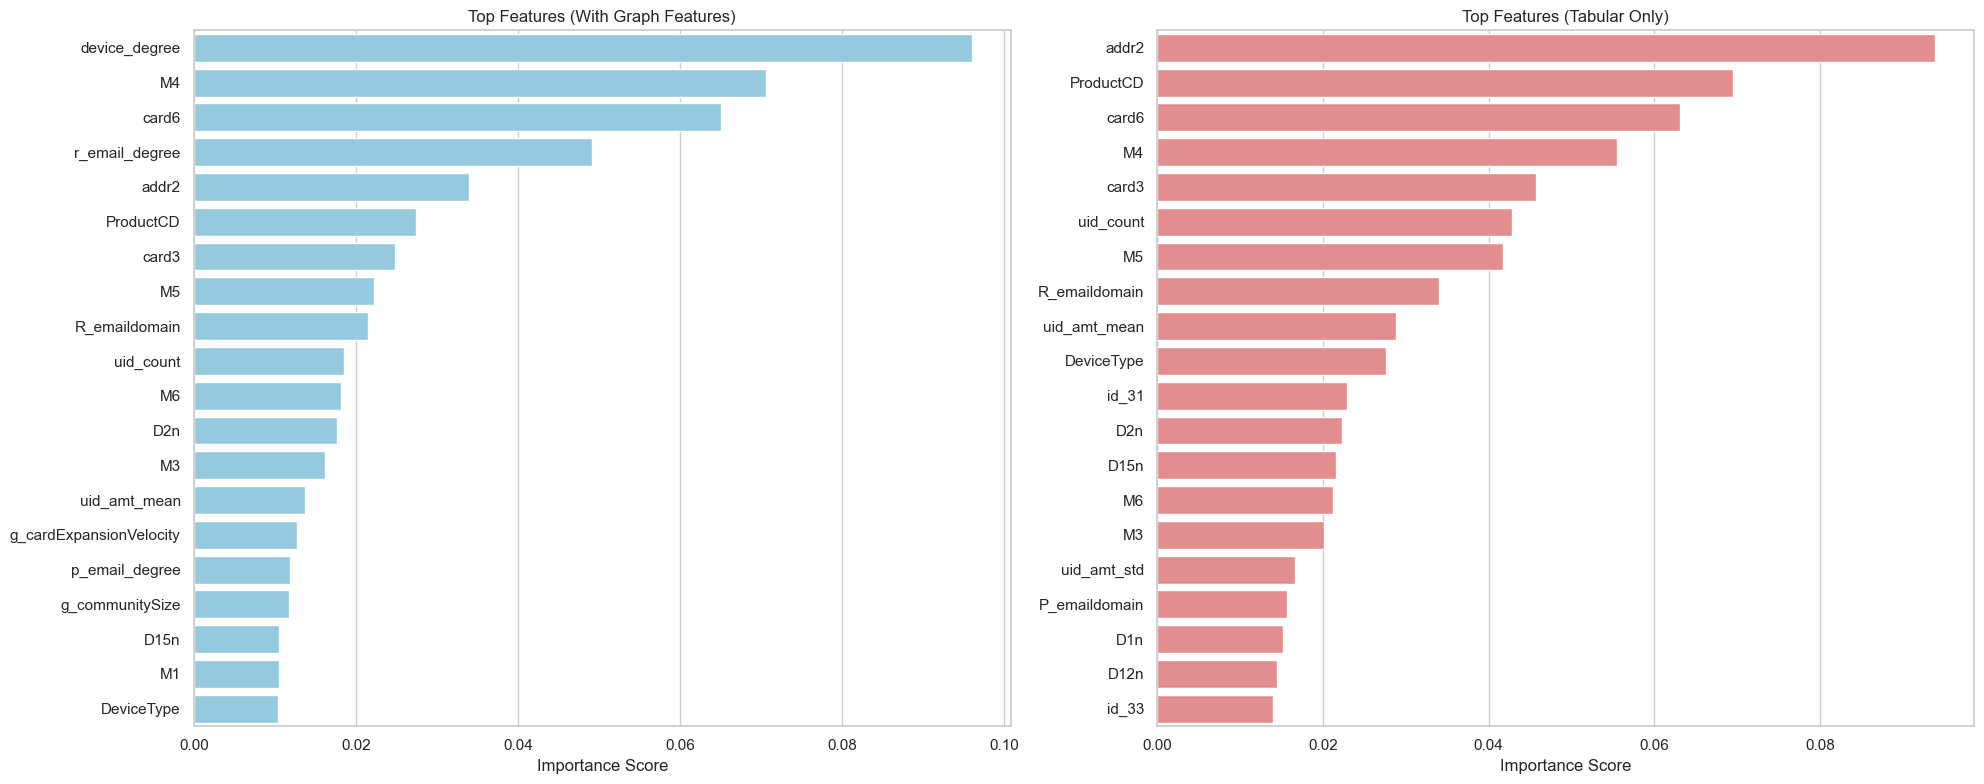

In [9]:
# Retrieve the last trained model from the CV results
model_graph = results['With Graph Features']['models'][-1]
model_no_graph = results['Without Graph Features']['models'][-1]

# Define feature sets
feat_names_graph = X.columns
feat_names_no_graph = X.drop(columns=graph_features).columns

def plot_importance(model, feat_names, title, ax, color):
    importance = model.feature_importances_
    df_imp = pd.DataFrame({'Feature': feat_names, 'Importance': importance})
    df_imp = df_imp.sort_values(by='Importance', ascending=False).head(20)
    
    sns.barplot(data=df_imp, x='Importance', y='Feature', ax=ax, color=color, orient='h')
    
    ax.set_title(title)
    ax.set_xlabel('Importance Score')
    ax.set_ylabel('') # Remove y label as feature names are self-explanatory

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

plot_importance(model_graph, feat_names_graph, 'Top Features (With Graph Features)', axes[0], 'skyblue')
plot_importance(model_no_graph, feat_names_no_graph, 'Top Features (Tabular Only)', axes[1], 'lightcoral')

plt.tight_layout()
plt.show()

## Inference on Test Set

Finally, we apply our best trained model to the separate `Test` dataset.

Note that the Test data was processed with the *same* graph feature engineering steps (isolated from training data to prevent leakage). Let's also plot the distribution of predicted fraud probabilities to see how well the model separates likely frauds from legitimate transactions.

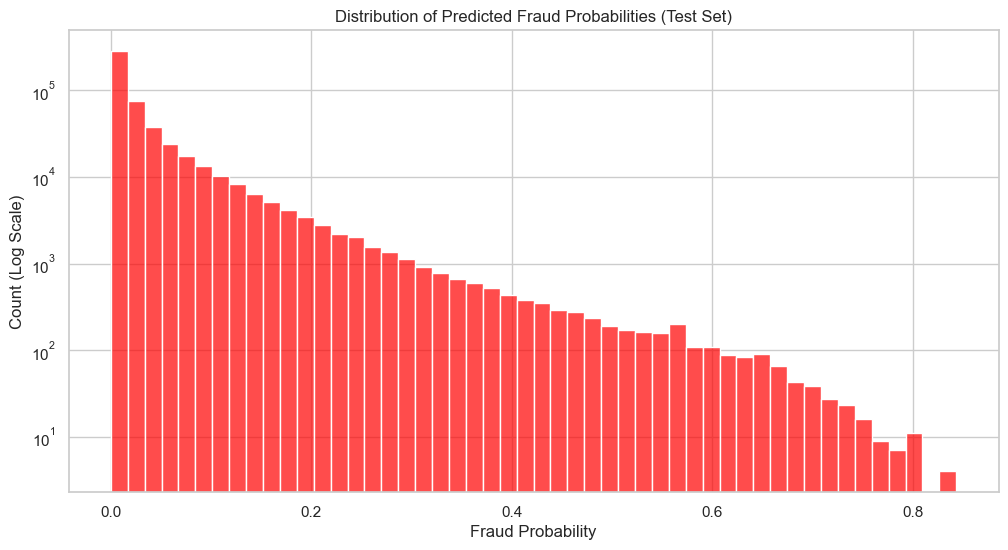

,TransactionID,isFraud
0,3663549,0.000392
1,3663550,0.003639
2,3663551,0.010049
3,3663552,0.006539
4,3663553,0.003271


In [10]:

# Prepare Test features
X_test = df_test.drop(columns=['TransactionID'])

# Predict
test_probs = model.predict_proba(X_test)[:, 1]

# Create Result DataFrame
submission = pd.DataFrame({
    'TransactionID': df_test['TransactionID'],
    'isFraud': test_probs
})

# Display distribution of fraud predictions
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.histplot(data=submission, x='isFraud', bins=50, color='red', alpha=0.7, kde=False)
plt.yscale('log')

plt.title('Distribution of Predicted Fraud Probabilities (Test Set)')
plt.xlabel('Fraud Probability')
plt.ylabel('Count (Log Scale)')
plt.show()

# Show sample
submission.head()

In [11]:
# Save submission file to CSV
submission.to_csv('fraud_submission.csv', index=False)